In [ ]:
import zipfile, os
from google.colab import drive

drive.mount('/content/drive', force_remount = True)

zip_path = '/content/drive/MyDrive/b.zip'
extract_path = '/content/drive/MyDrive/b'
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    files = zip_ref.namelist()
    for i, file in enumerate(files):
        zip_ref.extract(file, extract_path)
        if i % 500 == 0:
            print(f'{i}/{len(files)} files extracted...')

print(f"Done! {len(files)} files extracted to {extract_path}")

In [ ]:
import os

base = '/content/drive/MyDrive/b/Final.yolov8'

for folder in ['train', 'valid', 'test']:
    img_path = f'{base}/{folder}/images'
    lbl_path = f'{base}/{folder}/labels'

    n_img = len(os.listdir(img_path)) if os.path.exists(img_path) else 0
    n_lbl = len(os.listdir(lbl_path)) if os.path.exists(lbl_path) else 0
    print(f"{folder}: {n_img} images, {n_lbl} labels")

train: 4343 images, 805 labels
valid: 0 images, 0 labels
test: 277 images, 496 labels


In [ ]:
import os

zip_path = '/content/drive/MyDrive/b.zip'
size_mb = os.path.getsize(zip_path) / (1024 * 1024)
print(f"Size trên Drive: {size_mb:.1f} MB")

Size trên Drive: 462.3 MB


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.5 MB/s eta 0:00:00


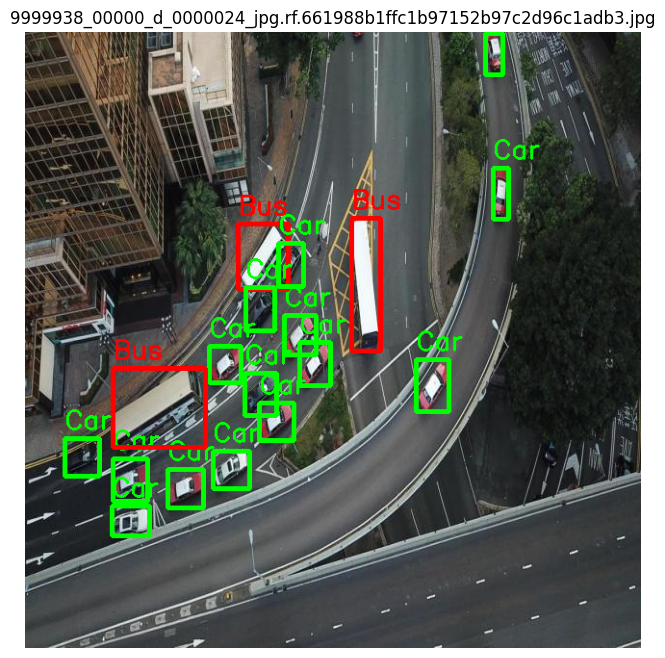

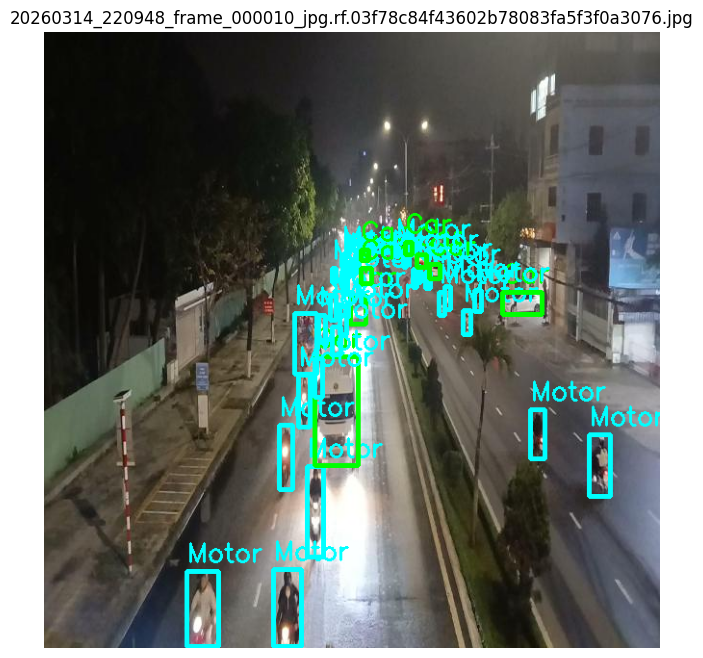

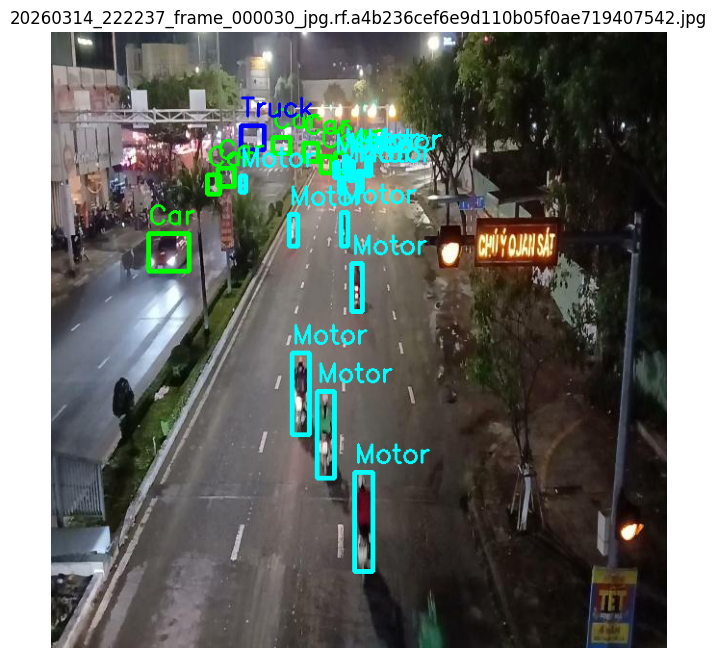

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os
import random
from glob import glob

def visualize_yolo_data(data_path, split='train', num_images=5):
    # Cấu hình đường dẫn
    img_dir = os.path.join(data_path, split, 'images')
    lbl_dir = os.path.join(data_path, split, 'labels')

    # Danh sách class theo thứ tự bạn đã remap
    # 0:bus, 1:car, 2:motor, 3:truck
    class_names = ['Bus', 'Car', 'Motor', 'Truck']
    colors = [(255, 0, 0), (0, 255, 0), (0, 255, 255), (0, 0, 255)] # Đỏ, Xanh lá, Vàng, Xanh dương

    # Lấy danh sách ảnh ngẫu nhiên
    img_list = glob(os.path.join(img_dir, "*.jpg"))
    if not img_list:
        print(f"Không tìm thấy ảnh tại: {img_dir}")
        return

    samples = random.sample(img_list, min(num_images, len(img_list)))

    for img_path in samples:
        # Đọc ảnh
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        # Tìm file nhãn tương ứng
        label_path = os.path.join(lbl_dir, os.path.basename(img_path).replace('.jpg', '.txt'))

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    cls, x, y, nw, nh = map(float, line.split())

                    # Chuyển từ tọa độ YOLO (0-1) sang Pixel
                    x1 = int((x - nw/2) * w)
                    y1 = int((y - nh/2) * h)
                    x2 = int((x + nw/2) * w)
                    y2 = int((y + nh/2) * h)

                    # Vẽ Bounding Box
                    color = colors[int(cls)] if int(cls) < len(colors) else (255, 255, 255)
                    cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)

                    # Ghi tên class
                    label_text = class_names[int(cls)] if int(cls) < len(class_names) else f"ID:{int(cls)}"
                    cv2.putText(img, label_text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

        # Hiển thị
        plt.figure(figsize=(12, 8))
        plt.imshow(img)
        plt.title(os.path.basename(img_path))
        plt.axis('off')
        plt.show()

# --- CHẠY THỬ ---
# Thay đổi đường dẫn này trỏ đến thư mục Final.yolov8 của bạn
DATA_PATH = '/content/drive/MyDrive/Work.yolov8'
visualize_yolo_data(DATA_PATH, split='train', num_images=3)

In [ ]:
!pip install Ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 78.2 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
import os

# 1. Mount Drive (Nếu bạn đã làm rồi thì bỏ qua bước này, nhưng làm lại cũng không sao)
drive.mount('/content/drive')

# 2. Định nghĩa chính xác đường dẫn có chữ 'MyDrive'
# Lưu ý: Viết hoa đúng chữ M và D trong MyDrive
DATA_PATH = '/content/drive/MyDrive/Work3.yolov8'

# 3. Kiểm tra sự tồn tại
if os.path.exists(DATA_PATH):
    print("✅ Chúc mừng! AI đã thấy thư mục gốc: ", DATA_PATH)

    # Kiểm tra sâu hơn vào thư mục train
    train_path = os.path.join(DATA_PATH, 'train/images')
    if os.path.exists(train_path):
        num_files = len(os.listdir(train_path))
        print(f"✅ Đã tìm thấy tập TRAIN. Tổng cộng có {num_files} ảnh.")
    else:
        print(f"❌ Vẫn không thấy thư mục TRAIN tại: {train_path}")
        print("Nội dung bên trong Work.yolov8 là:", os.listdir(DATA_PATH))
else:
    print("❌ Vẫn báo lỗi không tồn tại. Có thể do lỗi đồng bộ.")
    print("Danh sách các thư mục AI thấy trong Drive của bạn là:")
    print(os.listdir('/content/drive/MyDrive'))

Mounted at /content/drive
✅ Chúc mừng! AI đã thấy thư mục gốc:  /content/drive/MyDrive/Work3.yolov8
✅ Đã tìm thấy tập TRAIN. Tổng cộng có 3837 ảnh.


In [ ]:
import numpy as np
import torch
from ultralytics import YOLO

# ──────────────────────────────────────────────
# EB Observer
# ──────────────────────────────────────────────
class EB_Observer:
    def __init__(self, threshold=0.98):
        self.prev_mask = None
        self.threshold = threshold
        self.stable_epochs = 0

    def check_stability(self, model):
        gammas = []
        for m in model.modules():12
            if isinstance(m, torch.nn.BatchNorm2d):
                gammas.append(m.weight.data.abs().cpu().numpy())

        if not gammas:  # FIX 1: tránh crash nếu không tìm thấy BN layer
            return False

        all_gammas = np.concatenate(gammas)
        median = np.median(all_gammas)
        current_mask = all_gammas > median

        if self.prev_mask is not None:
            similarity = np.mean(current_mask == self.prev_mask)
            epoch = observer.stable_epochs
            print(f"  [EB] Cấu trúc ổn định: {similarity*100:.2f}% | streak: {self.stable_epochs}/5")

            if similarity > self.threshold:
                self.stable_epochs += 1
            else:
                self.stable_epochs = 0  # FIX 2: reset đúng chỗ (code gốc reset sau khi đã check)

        self.prev_mask = current_mask
        return self.stable_epochs >= 12


# ──────────────────────────────────────────────
# Callback
# ──────────────────────────────────────────────
observer = EB_Observer(threshold=0.995)

def on_train_epoch_end(trainer):
    is_stable = observer.check_stability(trainer.model)
    if is_stable:
        print("\n" + "="*60)
        print("!!! ĐÃ TÌM THẤY EB-TICKET: Cấu trúc đã ổn định !!!")
        print("!!! Bấm Ctrl+C ngay để dừng. Dùng best.pt để Pruning !!!")
        print("="*60 + "\n")
        # FIX 3: KHÔNG gọi trainer.save_checkpoint() thủ công
        # YOLOv8 tự lưu best.pt và last.pt sau mỗi epoch rồi
        # gọi thêm có thể ghi đè checkpoint sai thời điểm


# ──────────────────────────────────────────────
# Train
# ──────────────────────────────────────────────
model = YOLO('yolov8n.pt')
model.add_callback('on_train_epoch_end', on_train_epoch_end)

model.train(
    data='/content/drive/MyDrive/Work3.yolov8/data.yaml',
    epochs=150,
    imgsz=640,
    batch=32,
    optimizer='AdamW',
    lr0=0.001,

    box=10.0,
    cls=2.0,
    dfl=2.0,

    # Đã cover tĩnh
    fliplr=0.0,
    scale=0.0,
    hsv_s=0.0,
    hsv_v=0.0,
    erasing=0.0,

    # Chưa cover
    hsv_h=0.015,
    degrees=5.0,
    shear=2.0,
    perspective=0.0003,
    translate=0.1,
    mosaic=1.0,
    mixup=0.1,
    close_mosaic=20,
    copy_paste=0.3,

    cos_lr=True,
    device=0,
    project='/content/drive/MyDrive/PBL5_Final_Results',
    name='v8m_eb_observer'
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=10.0, cache=False, cfg=None, classes=None, close_mosaic=20, cls=2.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/Work3.yolov8/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=2.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.0, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.

KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn as nn
from ultralytics import YOLO
from ultralytics.models.yolo.detect import DetectionTrainer
from ultralytics.utils.loss import v8DetectionLoss

# 1. KHỞI TẠO TEACHER (Bản gốc best.pt)
teacher_model = YOLO('/content/drive/MyDrive/PBL5_Final_Results/v8m_eb_observer/weights/best.pt').model.cuda().eval()

# 2. ĐỊNH NGHĨA LỚP CUSTOM LOSS KẾ THỪA TỪ YOLOv8
class KDLoss(v8DetectionLoss):
    def __init__(self, trainer, teacher_model, alpha=0.5):
        super().__init__(trainer.model)
        self.teacher = teacher_model
        self.alpha = alpha # Tỉ lệ tin tưởng Teacher (0.5 là cân bằng)

    def __call__(self, preds, batch):
        # Tính Loss thông thường với nhãn (Box, Class, DFL)
        loss_gt, loss_items = super().__call__(preds, batch)

        # Lấy dự đoán từ Teacher (không tính gradient)
        with torch.no_grad():
            t_preds = self.teacher(batch['img'])

        # Tính Distillation Loss (MSE giữa feature maps/logits của Student và Teacher)
        # preds[1] thường chứa các feature maps trước khi qua Detect head
        loss_kd = 0
        for s, t in zip(preds[1], t_preds[1]):
            loss_kd += nn.functional.mse_loss(s, t)

        # Tổng hợp Loss
        total_loss = (1 - self.alpha) * loss_gt + self.alpha * loss_kd
        return total_loss, loss_items

# 3. MONKEY PATCHING: Ghi đè hàm khởi tạo Loss của Trainer
def get_distill_trainer(trainer):
    trainer.criterion = KDLoss(trainer, teacher_model)
    return trainer.criterion

# 4. CHUẨN BỊ STUDENT VÀ TRAINING
student_model = YOLO('/content/drive/MyDrive/yolov8n_slimmed.pt')

# Ép các channel đã zero-out phải giữ nguyên 0 (như bạn đã làm)
masks = {}
for name, m in student_model.model.named_modules():
    if isinstance(m, torch.nn.BatchNorm2d) and 'model.22' not in name:
        masks[name] = (m.weight.data == 0.0)

def on_train_batch_end(trainer):
    with torch.no_grad():
        for name, m in trainer.model.named_modules():
            if name in masks:
                m.weight.data[masks[name]] = 0.0
                m.bias.data[masks[name]] = 0.0

# 5. KÍCH HOẠT TRAIN VỚI CUSTOM LOSS
student_model.add_callback('on_pretrain_routine_start', lambda trainer: setattr(trainer, 'get_criterion', lambda: KDLoss(trainer, teacher_model)))
student_model.add_callback('on_train_batch_end', on_train_batch_end)

student_model.train(
    data='/content/drive/MyDrive/Final1.yolov8/data.yaml',
    epochs=70,
    imgsz=640,
    batch=32,
    lr0=0.0001,
    optimizer='AdamW',

    mosaic=1.0,
    mixup=0.2,
    copy_paste=0.4,

    project='/content/drive/MyDrive/PBL5_Final_Results',
    name='v8n_slimming_REAL_KD'
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.4, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Final1.yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=70, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=/content/drive/MyDrive/yolov8n_slimmed.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v8n_slimming_REAL_KD3, nbs=64, nms=False, opset=None, 

Exception in thread Thread-18 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/multiprocessing/reductions.py", line 540, in rebuild_storage_fd
    fd = df.detach()
         ^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/resource_

KeyboardInterrupt: 

In [ ]:
import torch
from ultralytics import YOLO
from copy import deepcopy

# 1. Load Student (Bản 0.586 mAP)
model = YOLO('/content/drive/MyDrive/PBL5_Final_Results/v8n_slimming_REAL_KD3/weights/best.pt')
old_model = model.model.cpu()
new_model = deepcopy(old_model) # Tạo bản sao để sửa cấu trúc

# 2. Thu thập chỉ số các channel "còn sống"
living_indices = {}
for name, m in old_model.named_modules():
    if isinstance(m, torch.nn.BatchNorm2d) and 'model.22' not in name:
        # Lấy index của các gamma khác 0
        mask = m.weight.data.abs() > 1e-5
        indices = torch.where(mask)[0]
        living_indices[name] = indices

# 3. Thông báo cắt tỉa
total_channels = sum(len(v) for v in living_indices.values())
print(f"Cấu trúc mới: Giữ lại {total_channels} channels tinh túy.")

# 4. Lưu ý quan trọng
# YOLOv8 có cấu trúc cực kỳ lồng ghép. Việc đổi shape của 1 layer
# yêu cầu đổi shape của layer liền sau nó (In_channels).

Cấu trúc mới: Giữ lại 4432 channels tinh túy.


In [ ]:
import torch
from ultralytics import YOLO
import numpy as np

# 1. Load model đã fine-tune KD
path = '/content/drive/MyDrive/PBL5_Final_Results/v8n_slimming_REAL_KD2/weights/best.pt'
model = YOLO(path)
raw_model = model.model.cpu()

print(f"--- NGHIỆM THU MÔ HÌNH: {path} ---")

# 2. Thống kê độ thưa (Sparsity Check)
total_bn_params = 0
zero_bn_params = 0
dead_channels = 0
total_channels = 0

for name, m in raw_model.named_modules():
    if isinstance(m, torch.nn.BatchNorm2d) and 'model.22' not in name:
        weights = m.weight.data.abs()
        total_bn_params += weights.numel()

        # Đếm các channel có trọng số siêu nhỏ (coi như bằng 0)
        mask = weights < 1e-6
        zero_bn_params += mask.sum().item()

        total_channels += weights.numel()
        dead_channels += mask.sum().item()

print(f"[*] Thống kê BatchNorm (Slimming):")
print(f"    - Tổng số Channels: {total_channels}")
print(f"    - Channels đã triệt tiêu: {dead_channels}")
print(f"    - Tỉ lệ thưa thực tế: {(dead_channels/total_channels)*100:.2f}%")

# 3. Kiểm tra lỗi Forward Pass (Sanity Check)
print(f"\n[*] Kiểm tra tính toàn vẹn (Forward Pass):")
try:
    dummy_input = torch.randn(1, 3, 640, 640)
    output = raw_model(dummy_input)
    print("    - Forward Pass: THÀNH CÔNG (Không lỗi cấu trúc)")
except Exception as e:
    print(f"    - Forward Pass: THẤT BẠI. Lỗi: {e}")

# 4. Test Tốc độ giả lập (Inference Benchmark trên CPU/GPU hiện tại)
print(f"\n[*] Benchmark nhanh (imgsz=640):")
results = model.predict(source=torch.randn(1, 3, 640, 640), imgsz=640, device='cuda', verbose=False)
print(f"    - Dự đoán thử: Thành công, tìm thấy {len(results[0].boxes)} vật thể giả lập.")

# 5. Xuất file thông số lớp (Layer-wise) để làm báo cáo
print(f"\n[!] Đã sẵn sàng xuất sang TensorRT.")

--- NGHIỆM THU MÔ HÌNH: /content/drive/MyDrive/PBL5_Final_Results/v8n_slimming_REAL_KD2/weights/best.pt ---
[*] Thống kê BatchNorm (Slimming):
    - Tổng số Channels: 4432
    - Channels đã triệt tiêu: 0
    - Tỉ lệ thưa thực tế: 0.00%

[*] Kiểm tra tính toàn vẹn (Forward Pass):
    - Forward Pass: THÀNH CÔNG (Không lỗi cấu trúc)

[*] Benchmark nhanh (imgsz=640):
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cpu 


ValueError: Invalid CUDA 'device=0' requested. Use 'device=cpu' or pass valid CUDA device(s) if available, i.e. 'device=0' or 'device=0,1,2,3' for Multi-GPU.

torch.cuda.is_available(): False
torch.cuda.device_count(): 0
os.environ['CUDA_VISIBLE_DEVICES']: None
See https://pytorch.org/get-started/locally/ for up-to-date torch install instructions if no CUDA devices are seen by torch.


In [ ]:
!pip install torch_pruning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 3.8 MB/s eta 0:00:00


In [ ]:
!pip install torch==2.8.0 torchvision==0.23.0 --quiet
!pip install nvidia-modelopt --quiet
!pip install git+https://github.com/ultralytics/ultralytics@qat-nvidia --quiet

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import sys
for key in list(sys.modules.keys()):
    if 'ultralytics' in key or 'torch' in key:
        del sys.modules[key]

from ultralytics import YOLO
import modelopt.torch.prune as mtp
import torch

model = YOLO('/content/drive/MyDrive/models/pruning/best.pt')

class PrunedTrainer(model.task_map[model.task]["trainer"]):
    def _setup_train(self):
        from ultralytics.utils import LOGGER
        from ultralytics.utils.torch_utils import ModelEMA
        import torch, math

        super()._setup_train()

        def collect_func(batch):
            return self.preprocess_batch(batch)["img"]

        def score_func(m):
            m.eval()
            self.validator.args.save = False
            self.validator.args.plots = False
            self.validator.args.verbose = False
            self.validator.is_coco = False
            metrics = self.validator(model=m)
            self.validator.args.save = self.args.save
            self.validator.args.plots = self.args.plots
            self.validator.args.verbose = self.args.verbose
            return metrics["fitness"]

        prune_constraints = {"flops": "80%"}  # YOLOv8n nhỏ → không prune quá mạnh

        self.model.is_fused = lambda: True

        self.model, prune_res = mtp.prune(
            model=self.model,
            mode="fastnas",
            constraints=prune_constraints,
            dummy_input=torch.randn(1, 3, self.args.imgsz, self.args.imgsz).to(self.device),
            config={
                "score_func": score_func,
                "checkpoint": "/content/modelopt_checkpoint.pth",
                "data_loader": self.train_loader,
                "collect_func": collect_func,
                "max_iter_data_loader": 20,
            },
        )

        self.model.to(self.device)
        self.ema = ModelEMA(self.model)

        weight_decay = self.args.weight_decay * self.batch_size * self.accumulate / self.args.nbs
        iterations = math.ceil(len(self.train_loader.dataset) / max(self.batch_size, self.args.nbs)) * self.epochs
        self.optimizer = self.build_optimizer(
            model=self.model,
            name=self.args.optimizer,
            lr=self.args.lr0,
            momentum=self.args.momentum,
            decay=weight_decay,
            iterations=iterations,
        )
        self._setup_scheduler()
        LOGGER.info("Applied pruning")

# Chỉ prune + fine-tune nhẹ để xem kết quả
results = model.train(
    data='/content/drive/MyDrive/Final1.yolov8/data.yaml',
    trainer=PrunedTrainer,
    epochs=50,
    imgsz=640,
    batch=16,
    lr0=0.0001,
    cos_lr=True,
    exist_ok=True,
    warmup_epochs=0,
    device=0,
    project='/content/drive/MyDrive/PBL5_Final_Results',
    name='v8n_modelopt_pruned'
)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


RuntimeError: function '_has_torch_function' already has a docstring

In [ ]:
!pip uninstall torchprofile -y
!pip install torchprofile==0.0.4

In [ ]:
from ultralytics import YOLO

# 1. Load mô hình bạn muốn đánh giá (Nano đã Prune hoặc Teacher Medium)
model_path = '/content/drive/MyDrive/PBL5_Final_Results/v8n_ModelOpt_Physical_Pruning_KD/weights/best.pt'
model = YOLO(model_path)

# 2. Chạy Validation
# data: Đường dẫn đến file data.yaml của bạn
# split: 'val' hoặc 'test' (tùy vào tập bạn muốn đánh giá)
# imgsz: Phải khớp với imgsz lúc bạn train (thường là 640)
# batch: Có thể để cao hơn lúc train vì không tốn Gradient
metrics = model.val(
    data='/content/drive/MyDrive/Work3.yolov8/data.yaml',
    split='test',
    imgsz=640,
    batch=32,
    conf=0.001, # Ngưỡng tự tin thấp để vẽ đường cong PR đầy đủ
    iou=0.6,    # Ngưỡng giao thoa
    device=0,   # Sử dụng GPU
    save_json=True # Lưu file json để nếu cần tính thêm metric khác
)

# 3. In các thông số quan trọng nhất
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


AttributeError: 'NoneType' object has no attribute 'float'

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/PBL5_Final_Results/v8n_ModelOpt_Physical_Pruning_KD/weights/best.pt")